# Facial Expression Recognition. MLP Baseline

In [18]:
!pip install wandb kaggle -q

In [19]:
from google.colab import userdata
import os
import wandb

wandb.login(key=userdata.get('WANDB_API_KEY'))
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


In [20]:
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge

!unzip -q challenges-in-representation-learning-facial-expression-recognition-challenge.zip

!ls -lh

challenges-in-representation-learning-facial-expression-recognition-challenge.zip: Skipping, found more recently modified local copy (use --force to force download)
replace example_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
total 952M
-rw-r--r-- 1 root root 286M Dec 11  2019 challenges-in-representation-learning-facial-expression-recognition-challenge.zip
-rw-r--r-- 1 root root  46K Jun 13 13:22 class_distribution.png
-rw-r--r-- 1 root root 7.1K Dec 11  2019 example_submission.csv
-rw-r--r-- 1 root root  92M Dec 11  2019 fer2013.tar.gz
-rw-r--r-- 1 root root 288M Dec 11  2019 icml_face_data.csv
-rw-r--r-- 1 root root  27K Jun 13 13:23 overfit_check.png
drwxr-xr-x 1 root root 4.0K Jun  4 13:39 sample_data
-rw-r--r-- 1 root root 122K Jun 13 13:22 sample_images.png
-rw-r--r-- 1 root root  58M Dec 11  2019 test.csv
-rw-r--r-- 1 root root 230M Dec 11  2019 train.csv
drwxr-xr-x 3 root root 4.0K Jun 13 13:28 wandb


# Data Loading;

In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv('icml_face_data.csv')

df.columns = df.columns.str.strip()

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nUsage split:")
print(df['Usage'].value_counts())
print("\nEmotion distribution:")
print(df['emotion'].value_counts().sort_index())

Shape: (35887, 3)
Columns: ['emotion', 'Usage', 'pixels']

Usage split:
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64

Emotion distribution:
emotion
0    4953
1     547
2    5121
3    8989
4    6077
5    4002
6    6198
Name: count, dtype: int64


In [25]:
import torch
from torch.utils.data import Dataset, DataLoader

train_df = df[df['Usage'] == 'Training'].reset_index(drop=True)
val_df   = df[df['Usage'] == 'PublicTest'].reset_index(drop=True)
test_df  = df[df['Usage'] == 'PrivateTest'].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("\nUsing device:", device)

Train size: 28709
Val size:   3589
Test size:  3589

Using device: cuda


In [26]:
import torchvision.transforms as transforms

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        pixels = np.array(self.dataframe.iloc[idx]['pixels'].split(),
                          dtype=np.uint8).reshape(48, 48)

        from PIL import Image
        image = Image.fromarray(pixels)

        if self.transform:
            image = self.transform(image)

        label = int(self.dataframe.iloc[idx]['emotion'])
        return image, label


transform = transforms.Compose([
    transforms.ToTensor()
])


train_dataset = FERDataset(train_df, transform=transform)
val_dataset   = FERDataset(val_df,   transform=transform)
test_dataset  = FERDataset(test_df,  transform=transform)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("One batch shape:", next(iter(train_loader))[0].shape)

One batch shape: torch.Size([64, 1, 48, 48])


# Forward Sanity Check

In [27]:
import torch.nn as nn

expected_initial_loss = np.log(7)
print(f"Expected initial loss for random model: {expected_initial_loss:.4f}")

class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(48 * 48, 7)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)

torch.manual_seed(42)
tiny_model = TinyMLP().to(device)
criterion = nn.CrossEntropyLoss()
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = tiny_model(images)
    loss = criterion(outputs, labels)

print(f"Actual initial loss:{loss.item():.4f}")

Expected initial loss for random model: 1.9459
Actual initial loss:1.9976


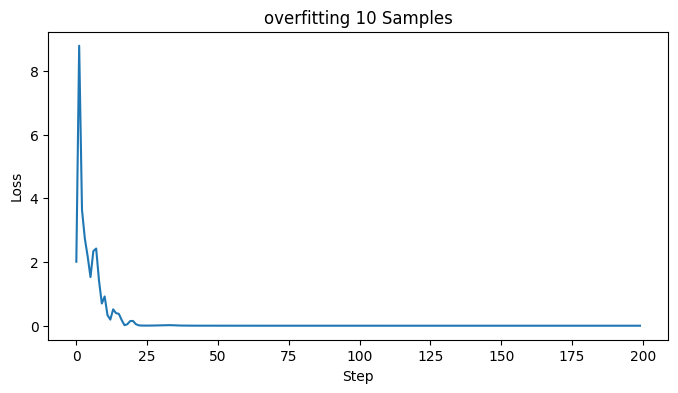

Final loss after 200 steps: 0.0001


In [28]:
small_images = images[:10]
small_labels = labels[:10]

tiny_model = TinyMLP().to(device)
optimizer = torch.optim.Adam(tiny_model.parameters(), lr=0.01)

losses = []
for step in range(200):
    optimizer.zero_grad()
    outputs = tiny_model(small_images)
    loss = criterion(outputs, small_labels)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.title('overfitting 10 Samples')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.savefig('overfit_check.png', dpi=150)
plt.show()

final_loss = losses[-1]
print(f"Final loss after 200 steps: {final_loss:.4f}")

# Architecture

In [29]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes, dropout_rate=0.0):
        super().__init__()

        layers = []
        input_size = 48 * 48

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 7))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

# Training

In [30]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            predicted = outputs.argmax(dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [31]:
def run_experiment(config, run_name):
    run = wandb.init(
        project="facial_expression_recognition",
        group="MLP",
        name=run_name,
        config=config
    )

    model = MLP(
        hidden_sizes=config['hidden_sizes'],
        dropout_rate=config['dropout_rate']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(config['epochs']):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        print(f"Epoch {epoch+1}/{config['epochs']} | "
              f"train Loss: {train_loss:.4f} | train Acc: {train_acc:.4f} | "
              f"val Loss: {val_loss:.4f} |val acc: {val_acc:.4f}")

    wandb.finish()
    return train_losses, val_losses, train_accs, val_accs

In [32]:
config_baseline = {
    'hidden_sizes': [512],
    'dropout_rate': 0.0,
    'lr': 0.001,
    'epochs': 30
}

baseline_train_losses, baseline_val_losses, \
baseline_train_accs, baseline_val_accs = run_experiment(config_baseline, 'MLP_baseline')

Epoch 1/30 | train Loss: 1.7745 | train Acc: 0.2858 | val Loss: 1.6889 |val acc: 0.3388
Epoch 2/30 | train Loss: 1.6969 | train Acc: 0.3294 | val Loss: 1.6580 |val acc: 0.3711
Epoch 3/30 | train Loss: 1.6673 | train Acc: 0.3455 | val Loss: 1.6561 |val acc: 0.3600
Epoch 4/30 | train Loss: 1.6451 | train Acc: 0.3556 | val Loss: 1.6468 |val acc: 0.3711
Epoch 5/30 | train Loss: 1.6344 | train Acc: 0.3603 | val Loss: 1.6405 |val acc: 0.3508
Epoch 6/30 | train Loss: 1.6145 | train Acc: 0.3710 | val Loss: 1.6284 |val acc: 0.3695
Epoch 7/30 | train Loss: 1.5993 | train Acc: 0.3773 | val Loss: 1.6345 |val acc: 0.3603
Epoch 8/30 | train Loss: 1.5898 | train Acc: 0.3789 | val Loss: 1.6046 |val acc: 0.3650
Epoch 9/30 | train Loss: 1.5817 | train Acc: 0.3835 | val Loss: 1.6044 |val acc: 0.3795
Epoch 10/30 | train Loss: 1.5765 | train Acc: 0.3858 | val Loss: 1.6000 |val acc: 0.3681
Epoch 11/30 | train Loss: 1.5671 | train Acc: 0.3870 | val Loss: 1.5973 |val acc: 0.3775
Epoch 12/30 | train Loss: 1.55

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▃▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇████
train_loss,█▆▆▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▄▃▄▂▄▃▄▅▄▅▆▇▅▇█▇█▆▆▇▇▅▇▇▇▇▇█▇
val_loss,█▆▆▆▅▅▅▄▄▃▃▂▃▂▂▁▂▁▂▂▁▂▃▂▃▁▂▁▁▂
epoch,30
train_acc,0.43725
train_loss,1.46261
val_acc,0.39705
val_loss,1.56511


In [33]:
config_wider = {
    'hidden_sizes': [1024, 512],
    'dropout_rate': 0.0,
    'lr': 0.001,
    'epochs': 30
}

wider_train_losses, wider_val_losses, \
wider_train_accs, wider_val_accs = run_experiment(config_wider, 'MLP_wider')

Epoch 1/30 | train Loss: 1.7654 | train Acc: 0.2855 | val Loss: 1.6896 |val acc: 0.3288
Epoch 2/30 | train Loss: 1.6917 | train Acc: 0.3299 | val Loss: 1.6465 |val acc: 0.3717
Epoch 3/30 | train Loss: 1.6563 | train Acc: 0.3483 | val Loss: 1.6307 |val acc: 0.3625
Epoch 4/30 | train Loss: 1.6347 | train Acc: 0.3588 | val Loss: 1.6178 |val acc: 0.3695
Epoch 5/30 | train Loss: 1.6161 | train Acc: 0.3667 | val Loss: 1.5960 |val acc: 0.3817
Epoch 6/30 | train Loss: 1.6055 | train Acc: 0.3737 | val Loss: 1.5898 |val acc: 0.3837
Epoch 7/30 | train Loss: 1.5919 | train Acc: 0.3763 | val Loss: 1.6147 |val acc: 0.3683
Epoch 8/30 | train Loss: 1.5861 | train Acc: 0.3800 | val Loss: 1.5614 |val acc: 0.3940
Epoch 9/30 | train Loss: 1.5687 | train Acc: 0.3870 | val Loss: 1.5783 |val acc: 0.3890
Epoch 10/30 | train Loss: 1.5577 | train Acc: 0.3909 | val Loss: 1.6149 |val acc: 0.3683
Epoch 11/30 | train Loss: 1.5467 | train Acc: 0.3968 | val Loss: 1.5628 |val acc: 0.3934
Epoch 12/30 | train Loss: 1.54

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇█▇███
train_loss,█▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▄▄▄▅▅▄▆▆▄▆▆▆▅▇▇▇▇▆▇▇█▆▇▇▇▇▇█▇
val_loss,█▆▅▅▄▄▅▂▃▅▃▂▃▃▂▂▁▁▂▂▂▁▃▂▂▁▁▃▁▁
epoch,30
train_acc,0.46362
train_loss,1.39329
val_acc,0.40763
val_loss,1.53777


In [34]:
config_dropout = {
    'hidden_sizes': [1024, 512],
    'dropout_rate': 0.5,
    'lr': 0.001,
    'epochs': 30
}

dropout_train_losses, dropout_val_losses, \
dropout_train_accs, dropout_val_accs = run_experiment(config_dropout, 'MLP_dropout')

Epoch 1/30 | train Loss: 1.8313 | train Acc: 0.2415 | val Loss: 1.7885 |val acc: 0.2513
Epoch 2/30 | train Loss: 1.7905 | train Acc: 0.2645 | val Loss: 1.7609 |val acc: 0.2714
Epoch 3/30 | train Loss: 1.7781 | train Acc: 0.2738 | val Loss: 1.7855 |val acc: 0.2583
Epoch 4/30 | train Loss: 1.7768 | train Acc: 0.2765 | val Loss: 1.7718 |val acc: 0.2700
Epoch 5/30 | train Loss: 1.7763 | train Acc: 0.2776 | val Loss: 1.7546 |val acc: 0.2917
Epoch 6/30 | train Loss: 1.7736 | train Acc: 0.2798 | val Loss: 1.7550 |val acc: 0.2834
Epoch 7/30 | train Loss: 1.7709 | train Acc: 0.2780 | val Loss: 1.7456 |val acc: 0.3026
Epoch 8/30 | train Loss: 1.7777 | train Acc: 0.2770 | val Loss: 1.7383 |val acc: 0.2895
Epoch 9/30 | train Loss: 1.7700 | train Acc: 0.2818 | val Loss: 1.7232 |val acc: 0.2973
Epoch 10/30 | train Loss: 1.7672 | train Acc: 0.2815 | val Loss: 1.7282 |val acc: 0.2831
Epoch 11/30 | train Loss: 1.7614 | train Acc: 0.2824 | val Loss: 1.7281 |val acc: 0.2998
Epoch 12/30 | train Loss: 1.76

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▅▆▆▇▇▇▆▇▇▇▇▇█▇▇█▇▇▇█▇█▇▇▇▇▃▃▃
train_loss,█▅▄▄▃▃▃▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▄▄▄
val_acc,▁▄▂▃▆▅▇▆▇▅▇█▆▅▅▅▃▅▅▅▄▆▆▆▁▂▁▁▁▁
val_loss,█▅█▆▅▅▄▃▂▂▂▂▃▃▃▄▆▃▅▄▃▃▁▂▆▆▇▇▅▆
epoch,30
train_acc,0.25494
train_loss,1.78472
val_acc,0.24965
val_loss,1.76718


In [35]:
def run_experiment_optimizer(optimizer_name, run_name):
    run = wandb.init(
        project="facial_expression_recognition",
        group="MLP",
        name=run_name,
        config={
            'hidden_sizes': [1024, 512],
            'dropout_rate': 0.0,
            'lr': 0.01,
            'epochs': 30,
            'optimizer': optimizer_name
        }
    )

    model = MLP(hidden_sizes=[1024, 512], dropout_rate=0.0).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == 'SGD':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == 'SGD_Momentum':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_name == 'NAG':
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9, nesterov=True)
    elif optimizer_name == 'Adagrad':
        optimizer = torch.optim.Adagrad(model.parameters(), lr=0.01)
    elif optimizer_name == 'Adadelta':
        optimizer = torch.optim.Adadelta(model.parameters())
    elif optimizer_name == 'RMSprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=0.01)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(30):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        wandb.log({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        })

        print(f"[{optimizer_name}] Epoch {epoch+1}/30 | "
              f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    wandb.finish()
    return train_losses, val_losses, train_accs, val_accs


optimizers_to_test = ['SGD', 'SGD_Momentum', 'NAG', 'Adagrad', 'Adadelta', 'RMSprop']
optimizer_results = {}

for opt_name in optimizers_to_test:
    print(f"\n{'='*40}")
    print(f"Training with {opt_name}")
    print(f"{'='*40}")
    results = run_experiment_optimizer(opt_name, f'MLP_{opt_name}')
    optimizer_results[opt_name] = results

import numpy as np
for opt_name, (tl, vl, ta, va) in optimizer_results.items():
    np.save(f'results_{opt_name}.npy', [tl, vl, ta, va])


Training with SGD


[SGD] Epoch 1/30 | Train Acc: 0.2511 | Val Acc: 0.2519
[SGD] Epoch 2/30 | Train Acc: 0.2609 | Val Acc: 0.2566
[SGD] Epoch 3/30 | Train Acc: 0.2923 | Val Acc: 0.3455
[SGD] Epoch 4/30 | Train Acc: 0.3252 | Val Acc: 0.3243
[SGD] Epoch 5/30 | Train Acc: 0.3374 | Val Acc: 0.3330
[SGD] Epoch 6/30 | Train Acc: 0.3473 | Val Acc: 0.3664
[SGD] Epoch 7/30 | Train Acc: 0.3523 | Val Acc: 0.3750
[SGD] Epoch 8/30 | Train Acc: 0.3564 | Val Acc: 0.3561
[SGD] Epoch 9/30 | Train Acc: 0.3634 | Val Acc: 0.3541
[SGD] Epoch 10/30 | Train Acc: 0.3649 | Val Acc: 0.3817
[SGD] Epoch 11/30 | Train Acc: 0.3679 | Val Acc: 0.3887
[SGD] Epoch 12/30 | Train Acc: 0.3747 | Val Acc: 0.3745
[SGD] Epoch 13/30 | Train Acc: 0.3760 | Val Acc: 0.3553
[SGD] Epoch 14/30 | Train Acc: 0.3814 | Val Acc: 0.3480
[SGD] Epoch 15/30 | Train Acc: 0.3849 | Val Acc: 0.3656
[SGD] Epoch 16/30 | Train Acc: 0.3849 | Val Acc: 0.3879
[SGD] Epoch 17/30 | Train Acc: 0.3898 | Val Acc: 0.3709
[SGD] Epoch 18/30 | Train Acc: 0.3906 | Val Acc: 0.3890
[

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▁▃▄▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████
train_loss,█▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▁▅▄▅▆▇▆▆▇▇▇▆▅▆▇▆▇▇▇▅▆▅█▇█▇██▇
val_loss,█▇▆▅▅▄▄▄▄▃▃▄▄▄▃▃▃▂▂▂▅▃▅▂▂▂▂▁▁▂
epoch,30
train_acc,0.42753
train_loss,1.49347
val_acc,0.39454
val_loss,1.57012



Training with SGD_Momentum


[SGD_Momentum] Epoch 1/30 | Train Acc: 0.2843 | Val Acc: 0.3491
[SGD_Momentum] Epoch 2/30 | Train Acc: 0.3310 | Val Acc: 0.3594
[SGD_Momentum] Epoch 3/30 | Train Acc: 0.3502 | Val Acc: 0.3597
[SGD_Momentum] Epoch 4/30 | Train Acc: 0.3585 | Val Acc: 0.3279
[SGD_Momentum] Epoch 5/30 | Train Acc: 0.3681 | Val Acc: 0.3611
[SGD_Momentum] Epoch 6/30 | Train Acc: 0.3761 | Val Acc: 0.3463
[SGD_Momentum] Epoch 7/30 | Train Acc: 0.3747 | Val Acc: 0.3853
[SGD_Momentum] Epoch 8/30 | Train Acc: 0.3809 | Val Acc: 0.3753
[SGD_Momentum] Epoch 9/30 | Train Acc: 0.3921 | Val Acc: 0.3851
[SGD_Momentum] Epoch 10/30 | Train Acc: 0.3990 | Val Acc: 0.3965
[SGD_Momentum] Epoch 11/30 | Train Acc: 0.4079 | Val Acc: 0.3993
[SGD_Momentum] Epoch 12/30 | Train Acc: 0.4132 | Val Acc: 0.3742
[SGD_Momentum] Epoch 13/30 | Train Acc: 0.4176 | Val Acc: 0.3965
[SGD_Momentum] Epoch 14/30 | Train Acc: 0.4262 | Val Acc: 0.3683
[SGD_Momentum] Epoch 15/30 | Train Acc: 0.4249 | Val Acc: 0.4213
[SGD_Momentum] Epoch 16/30 | Train

...

[Adadelta] Epoch 1/30 | Train Acc: 0.2512 | Val Acc: 0.2717
[Adadelta] Epoch 2/30 | Train Acc: 0.2909 | Val Acc: 0.3357
[Adadelta] Epoch 3/30 | Train Acc: 0.3159 | Val Acc: 0.3004
[Adadelta] Epoch 4/30 | Train Acc: 0.3309 | Val Acc: 0.3614
[Adadelta] Epoch 5/30 | Train Acc: 0.3398 | Val Acc: 0.2926
[Adadelta] Epoch 6/30 | Train Acc: 0.3454 | Val Acc: 0.3619
[Adadelta] Epoch 7/30 | Train Acc: 0.3551 | Val Acc: 0.3324
[Adadelta] Epoch 8/30 | Train Acc: 0.3599 | Val Acc: 0.3536
[Adadelta] Epoch 9/30 | Train Acc: 0.3679 | Val Acc: 0.3238
[Adadelta] Epoch 10/30 | Train Acc: 0.3740 | Val Acc: 0.3536
[Adadelta] Epoch 11/30 | Train Acc: 0.3774 | Val Acc: 0.3611
[Adadelta] Epoch 12/30 | Train Acc: 0.3806 | Val Acc: 0.3522
[Adadelta] Epoch 13/30 | Train Acc: 0.3850 | Val Acc: 0.3572
[Adadelta] Epoch 14/30 | Train Acc: 0.3904 | Val Acc: 0.3759
[Adadelta] Epoch 15/30 | Train Acc: 0.3909 | Val Acc: 0.3759
[Adadelta] Epoch 16/30 | Train Acc: 0.3991 | Val Acc: 0.3622
[Adadelta] Epoch 17/30 | Train Ac

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
train_loss,█▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▁▅▃▆▂▆▅▆▄▆▆▆▆▇▇▆▇▇▆▄▇█▆▇▇▇▆▇██
val_loss,▅▄▆▃▆▂▃▂▄▂▂▂▂▁▂▂▁▂▄▇▂▃▂▁▄▆▄▄▃█
epoch,30
train_acc,0.45317
train_loss,1.42801
val_acc,0.39036
val_loss,1.87315



Training with RMSprop


[RMSprop] Epoch 1/30 | Train Acc: 0.2395 | Val Acc: 0.2497
[RMSprop] Epoch 2/30 | Train Acc: 0.2516 | Val Acc: 0.2497
[RMSprop] Epoch 3/30 | Train Acc: 0.2479 | Val Acc: 0.2497
[RMSprop] Epoch 4/30 | Train Acc: 0.2515 | Val Acc: 0.2497
[RMSprop] Epoch 5/30 | Train Acc: 0.2502 | Val Acc: 0.2497
[RMSprop] Epoch 6/30 | Train Acc: 0.2488 | Val Acc: 0.2499
[RMSprop] Epoch 7/30 | Train Acc: 0.2504 | Val Acc: 0.2497
[RMSprop] Epoch 8/30 | Train Acc: 0.2502 | Val Acc: 0.2502
[RMSprop] Epoch 9/30 | Train Acc: 0.2508 | Val Acc: 0.2497
[RMSprop] Epoch 10/30 | Train Acc: 0.2518 | Val Acc: 0.2499
[RMSprop] Epoch 11/30 | Train Acc: 0.2518 | Val Acc: 0.2497
[RMSprop] Epoch 12/30 | Train Acc: 0.2518 | Val Acc: 0.2497
[RMSprop] Epoch 13/30 | Train Acc: 0.2518 | Val Acc: 0.2497
[RMSprop] Epoch 14/30 | Train Acc: 0.2518 | Val Acc: 0.2497
[RMSprop] Epoch 15/30 | Train Acc: 0.2518 | Val Acc: 0.2497
[RMSprop] Epoch 16/30 | Train Acc: 0.2518 | Val Acc: 0.2497
[RMSprop] Epoch 17/30 | Train Acc: 0.2518 | Val A

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁█▆█▇▆▇▇▇█████████████████████
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▁▁▁▁▄▁█▁▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,▁▃▄▂▁▂▅█▅▆▆▂▁▁▂▂▄▃▁▂▂▁▂▃▃▂▁▄▄▂
epoch,30
train_acc,0.2518
train_loss,1.80983
val_acc,0.24965
val_loss,1.80909


In [ ]:
class MLPWithBatchNorm(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = []
        input_size = 48 * 48

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 7))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


run = wandb.init(
    project="facial_expression_recognition",
    group="MLP",
    name="MLP_batchnorm",
    config={
        'hidden_sizes': [1024, 512],
        'epochs': 30,
        'lr': 0.001,
        'optimizer': 'Adam',
        'batch_norm': True
    }
)

model_bn = MLPWithBatchNorm([1024, 512]).to(device)
optimizer = torch.optim.Adam(model_bn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

bn_train_losses, bn_val_losses, bn_train_accs, bn_val_accs = [], [], [], []

for epoch in range(30):
    train_loss, train_acc = train_epoch(model_bn, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_bn, val_loader, criterion)

    bn_train_losses.append(train_loss)
    bn_val_losses.append(val_loss)
    bn_train_accs.append(train_acc)
    bn_val_accs.append(val_acc)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    })

    print(f"Epoch {epoch+1}/30 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

wandb.finish()

In [40]:
run = wandb.init(
    project="facial_expression_recognition",
    group="MLP",
    name="MLP_batchnorm_dropout",
    config={
        'hidden_sizes': [1024, 512],
        'epochs': 30,
        'lr': 0.001,
        'optimizer': 'Adam',
        'batch_norm': True,
        'dropout_rate': 0.3
    }
)

class MLPBatchNormDropout(nn.Module):
    def __init__(self, hidden_sizes, dropout_rate=0.3):
        super().__init__()
        layers = []
        input_size = 48 * 48
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_size = hidden_size
        layers.append(nn.Linear(input_size, 7))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

model_bn_dp = MLPBatchNormDropout([1024, 512], dropout_rate=0.3).to(device)
optimizer = torch.optim.Adam(model_bn_dp.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

bn_dp_train_losses, bn_dp_val_losses, bn_dp_train_accs, bn_dp_val_accs = [], [], [], []

for epoch in range(30):
    train_loss, train_acc = train_epoch(model_bn_dp, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model_bn_dp, val_loader, criterion)

    bn_dp_train_losses.append(train_loss)
    bn_dp_val_losses.append(val_loss)
    bn_dp_train_accs.append(train_acc)
    bn_dp_val_accs.append(val_acc)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_acc': train_acc,
        'val_acc': val_acc
    })

    print(f"Epoch {epoch+1}/30 | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

wandb.finish()

Epoch 1/30 | Train Acc: 0.3303 | Val Acc: 0.3530
Epoch 2/30 | Train Acc: 0.3758 | Val Acc: 0.3867
Epoch 3/30 | Train Acc: 0.3964 | Val Acc: 0.3909
Epoch 4/30 | Train Acc: 0.4140 | Val Acc: 0.3561
Epoch 5/30 | Train Acc: 0.4331 | Val Acc: 0.3892
Epoch 6/30 | Train Acc: 0.4433 | Val Acc: 0.4138
Epoch 7/30 | Train Acc: 0.4619 | Val Acc: 0.4213
Epoch 8/30 | Train Acc: 0.4716 | Val Acc: 0.4099
Epoch 9/30 | Train Acc: 0.4901 | Val Acc: 0.4087
Epoch 10/30 | Train Acc: 0.5059 | Val Acc: 0.4082
Epoch 11/30 | Train Acc: 0.5156 | Val Acc: 0.4224
Epoch 12/30 | Train Acc: 0.5362 | Val Acc: 0.4012
Epoch 13/30 | Train Acc: 0.5515 | Val Acc: 0.4252
Epoch 14/30 | Train Acc: 0.5637 | Val Acc: 0.4062
Epoch 15/30 | Train Acc: 0.5800 | Val Acc: 0.4093
Epoch 16/30 | Train Acc: 0.5914 | Val Acc: 0.4238
Epoch 17/30 | Train Acc: 0.6113 | Val Acc: 0.4179
Epoch 18/30 | Train Acc: 0.6220 | Val Acc: 0.4076
Epoch 19/30 | Train Acc: 0.6397 | Val Acc: 0.4377
Epoch 20/30 | Train Acc: 0.6517 | Val Acc: 0.4492
Epoch 21/

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇████
train_loss,█▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁
val_acc,▁▃▄▁▃▅▆▅▅▅▆▄▆▅▅▆▅▅▇█▇█▅█▆█▅▅██
val_loss,▂▂▂▂▂▁▁▁▁▂▂▂▂▂▂▂▂▄▂▂▂▃▄▅▅▄▄█▅▄
epoch,30
train_acc,0.75523
train_loss,0.6618
val_acc,0.45444
val_loss,1.82732


# Analysis

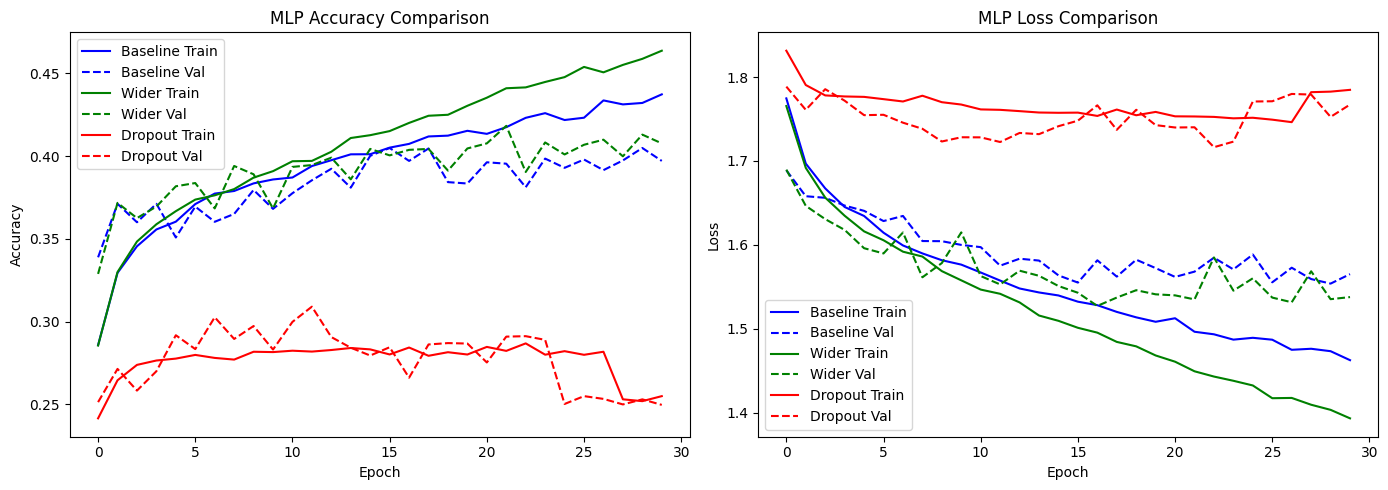

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# accuracy
axes[0].plot(baseline_train_accs, label='Baseline Train', color='blue')
axes[0].plot(baseline_val_accs, label='Baseline Val', color='blue', linestyle='--')
axes[0].plot(wider_train_accs, label='Wider Train', color='green')
axes[0].plot(wider_val_accs, label='Wider Val', color='green', linestyle='--')
axes[0].plot(dropout_train_accs, label='Dropout Train', color='red')
axes[0].plot(dropout_val_accs, label='Dropout Val', color='red', linestyle='--')
axes[0].set_title('MLP Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

#loss
axes[1].plot(baseline_train_losses, label='Baseline Train', color='blue')
axes[1].plot(baseline_val_losses, label='Baseline Val', color='blue', linestyle='--')
axes[1].plot(wider_train_losses, label='Wider Train', color='green')
axes[1].plot(wider_val_losses, label='Wider Val', color='green', linestyle='--')
axes[1].plot(dropout_train_losses, label='Dropout Train', color='red')
axes[1].plot(dropout_val_losses, label='Dropout Val', color='red', linestyle='--')
axes[1].set_title('MLP Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_comparison.png', dpi=150)
plt.show()

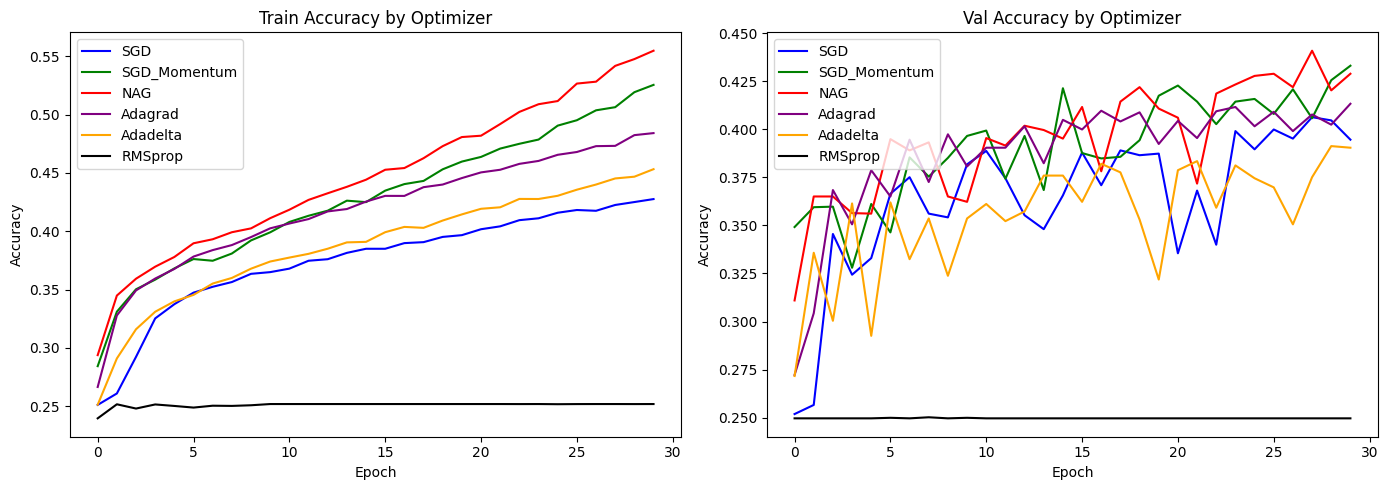

In [37]:
import matplotlib.pyplot as plt
import numpy as np

optimizer_names = ['SGD', 'SGD_Momentum', 'NAG', 'Adagrad', 'Adadelta', 'RMSprop']
optimizer_results = {}
for opt_name in optimizer_names:
    data = np.load(f'results_{opt_name}.npy', allow_pickle=True)
    optimizer_results[opt_name] = data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'SGD': 'blue',
    'SGD_Momentum': 'green',
    'NAG': 'red',
    'Adagrad': 'purple',
    'Adadelta': 'orange',
    'RMSprop': 'black'
}

for opt_name, (tl, vl, ta, va) in optimizer_results.items():
    axes[0].plot(ta, label=opt_name, color=colors[opt_name])
    axes[1].plot(va, label=opt_name, color=colors[opt_name])

axes[0].set_title('Train Accuracy by Optimizer')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Val Accuracy by Optimizer')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_optimizer_comparison.png', dpi=150)
plt.show()

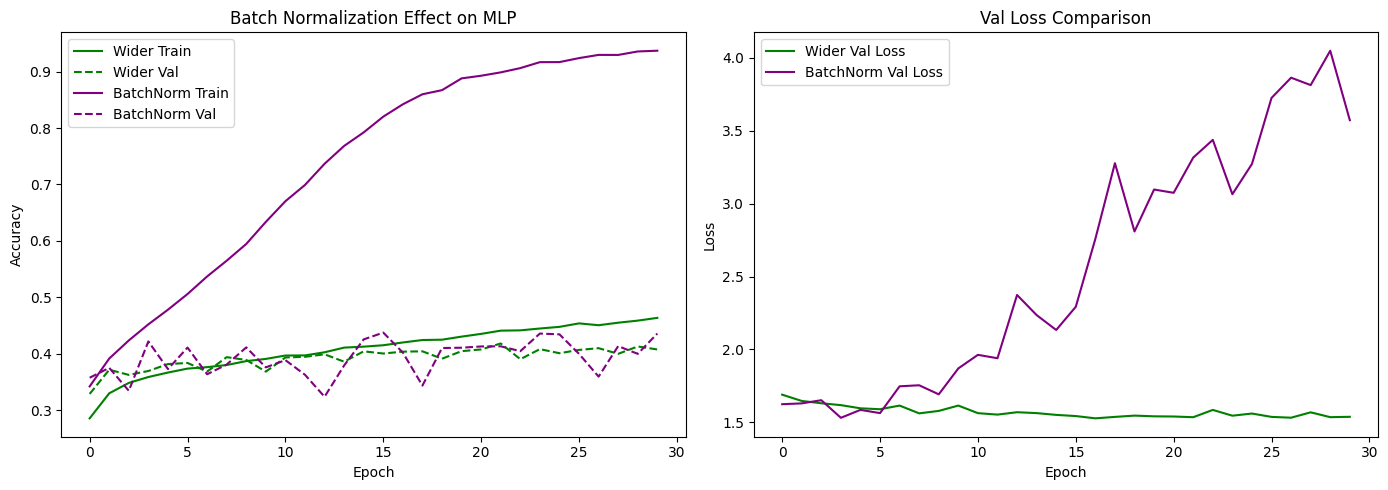

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(wider_train_accs, label='Wider Train', color='green')
axes[0].plot(wider_val_accs, label='Wider Val', color='green', linestyle='--')
axes[0].plot(bn_train_accs, label='BatchNorm Train', color='purple')
axes[0].plot(bn_val_accs, label='BatchNorm Val', color='purple', linestyle='--')
axes[0].set_title('Batch Normalization Effect on MLP')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(wider_val_losses, label='Wider Val Loss', color='green')
axes[1].plot(bn_val_losses, label='BatchNorm Val Loss', color='purple')
axes[1].set_title('Val Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_batchnorm_comparison.png', dpi=150)
plt.show()

In [6]:
from google.colab import userdata
import wandb
import matplotlib.pyplot as plt

wandb.login(key=userdata.get('WANDB_API_KEY'))

api = wandb.Api()

def get_history(run_name):
    runs = api.runs("gdzag22-free-university-of-tbilisi-/facial_expression_recognition")
    for run in runs:
        if run.name == run_name:
            h = run.history()
            return h['train_acc'].tolist(), h['val_acc'].tolist(), h['train_loss'].tolist(), h['val_loss'].tolist()

run_names = ['MLP_baseline', 'MLP_wider', 'MLP_dropout', 'MLP_batchnorm', 'MLP_batchnorm_dropout']
results = {name: get_history(name) for name in run_names}

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: gdzag22 (gdzag22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


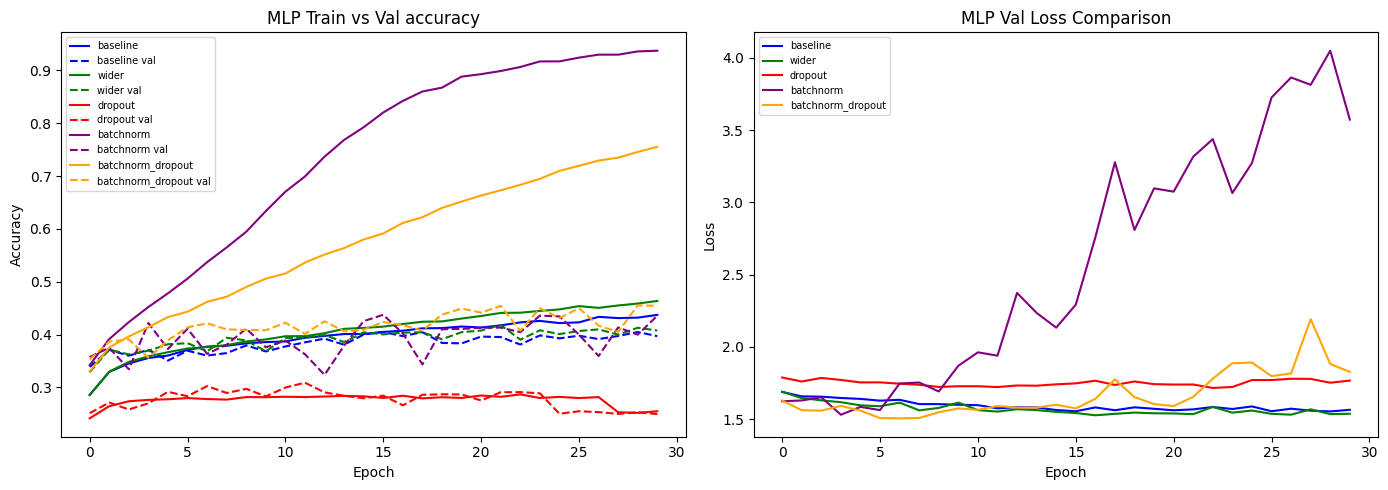

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'MLP_baseline': 'blue',
    'MLP_wider': 'green',
    'MLP_dropout': 'red',
    'MLP_batchnorm': 'purple',
    'MLP_batchnorm_dropout': 'orange'
}

for run_name, (ta, va, tl, vl) in results.items():
    label = run_name.replace('MLP_', '')
    axes[0].plot(ta, label=label, color=colors[run_name])
    axes[0].plot(va, label=f'{label} val', color=colors[run_name], linestyle='--')

axes[0].set_title('MLP Train vs Val accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=7)

for run_name, (ta, va, tl, vl) in results.items():
    label = run_name.replace('MLP_', '')
    axes[1].plot(vl, label=label, color=colors[run_name])

axes[1].set_title('MLP Val Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('mlp_all_comparison.png', dpi=150)
plt.show()